# Log Odds Ratio Test Plots

Generates log odds ratio test plots found in [Fig. 5](figures/figure_5) and the [Supplementary Figures](figures/supplementary)

## Notebook Workflow

1. Load stage-05 odds-ratio result pickle files.
2. Generate the main odds-ratio distribution and summary plots.
3. Produce supplementary variants used in figure panels.
4. Save final figure outputs with publication settings.

In [26]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Resolve repo root whether cwd is repo root, scripts/, or a stage subdirectory.
cwd = os.getcwd()
if os.path.basename(cwd) == "orb-selection":
    repo_root = cwd
elif os.path.basename(os.path.dirname(cwd)) == "orb-selection":
    repo_root = os.path.dirname(cwd)
elif os.path.basename(os.path.dirname(os.path.dirname(cwd))) == "orb-selection":
    repo_root = os.path.dirname(os.path.dirname(cwd))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
stage04_path = os.path.join(repo_root, "scripts", "04_permulation_loss_dup")
for path in (src_path, stage04_path):
    if path not in sys.path:
        sys.path.insert(0, path)

print(f"Using src path: {src_path}")
print(f"Using stage-04 path: {stage04_path}")

%load_ext autoreload
%autoreload 2

import importlib
import odds_ratio_test as ort
import odds_ratio_test_plotting as ortplot

print("odds_ratio_test:", ort.__file__)
print("odds_ratio_test_plotting:", ortplot.__file__)

importlib.reload(ortplot)
importlib.reload(ort)

figure5 = os.path.join(repo_root, "figures", "figure_5")
supp = os.path.join(repo_root, "figures", "supplementary")


Using src path: /Users/calvin/orb-selection/src
Using stage-04 path: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
odds_ratio_test: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup/odds_ratio_test.py
odds_ratio_test_plotting: /Users/calvin/orb-selection/scripts/04_permulation_loss_dup/odds_ratio_test_plotting.py


In [3]:
%autoreload 2

# Centralize all odds-ratio result paths and pickle loads used below.
ort_dir_all = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr14/Run1_occ_30-95_10000x_all_orb")
ort_dir_no_ara = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr14/Run2_occ_30-65_10000x_no_ara")
ort_dir_no_ara_other_perm = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr13/Run2_occ_30-65_10000x")
ort_dir_no_tet = os.path.join(repo_root, "results/odds_ratio_test/Results_Apr14/Run3_occ_30-81_10000x_no_tet")

results = ort.PermulationTestResults.load_from_pickle(f"{ort_dir_all}/results.pkl")
no_ara_results = ort.PermulationTestResults.load_from_pickle(f"{ort_dir_no_ara}/results.pkl")
no_ara_results_other_permulation = ort.PermulationTestResults.load_from_pickle(f"{ort_dir_no_ara_other_perm}/results.pkl")
no_tet_results = ort.PermulationTestResults.load_from_pickle(f"{ort_dir_no_tet}/results.pkl")

In [30]:
def extract_max_bin_values(results, binwidth=0.001):
    # Values in the highest-count histogram bin (matches this loss-all stats setup).
    vals = results.means_loss

    xmin = np.floor(vals.min() / binwidth) * binwidth
    xmax = np.ceil(vals.max() / binwidth) * binwidth
    edges = np.arange(xmin, xmax + binwidth, binwidth)

    counts, edges = np.histogram(vals, bins=edges)
    max_idx = int(np.argmax(counts))
    left_edge, right_edge = edges[max_idx], edges[max_idx + 1]

    # Include right edge only if this is the last bin.
    if max_idx == len(counts) - 1:
        max_bin_values = vals[(vals >= left_edge) & (vals <= right_edge)]
    else:
        max_bin_values = vals[(vals >= left_edge) & (vals < right_edge)]

    unique_in_max_bin = np.unique(max_bin_values)

    print(f"Max-count bin index: {max_idx}")
    print(f"Bin range: [{left_edge:.6f}, {right_edge:.6f}{']' if max_idx == len(counts)-1 else ')'}")
    print(f"Count in max bin: {counts[max_idx]}")
    print(f"Unique values in max bin: {len(unique_in_max_bin)}")
    print(f"Extracted values: {len(max_bin_values)}")

    return max_bin_values, unique_in_max_bin

## Results - main version (including all orb-weavers)

In [3]:
results.loss_ci_av

array([-2.84580953,  2.83430826])

In [4]:
results.dup_ci_av

array([-2.16984876,  2.17796818])

### Loss (all)

(<Figure size 600x500 with 1 Axes>,
 <Axes: xlabel='Log odds ratio', ylabel='Density'>)

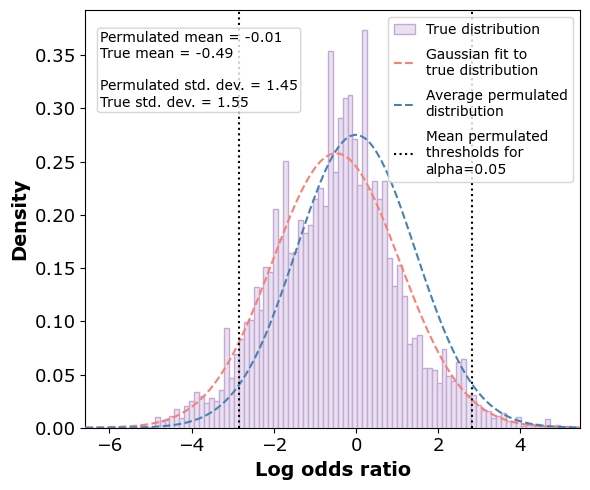

In [5]:
%autoreload 2
ortplot.plot_permulation_results(
    results,
    "loss",
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    gaussfit_color="salmon",
    avpermulation_color="steelblue",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    thresholds_color="black",
    title=False,
    legend_fontsize=10,
    textbox_fontsize=10,
    axis_label_fontsize=14,
 )

# plt.savefig(str(figure5 + "loss_results.png"), dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig(str(ort_results + "Run1_Loss_LT_50-95_10000x/loss_occ50-95_less_permutation_results.png"), dpi=300, bbox_inches="tight")

### Duplication (all)

(<Figure size 600x500 with 1 Axes>,
 <Axes: xlabel='Log odds ratio', ylabel='Density'>)

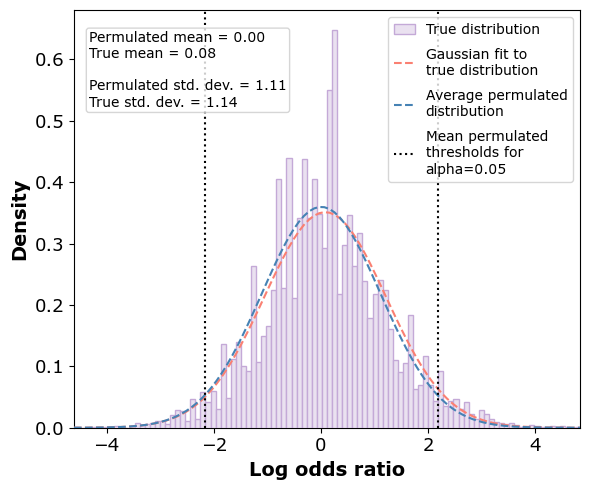

In [6]:
%autoreload 2
ortplot.plot_permulation_results(
    results,
    "duplication",
    fg_name="orbweavers",
    bg_name="non-orbweavers",
    gaussfit_color="salmon",
    avpermulation_color="steelblue",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    thresholds_color="black",
    title=False,
    legend_fontsize=10,
    textbox_fontsize=10,
    axis_label_fontsize=14
)

# plt.savefig(str(figure5 + "dup_results.png"), dpi=300, bbox_inches="tight", transparent=True)
# plt.savefig(str(ort_results + "Run2_Dup_RT_50-max_10000x/dup_occ50-98_greater_permutation_results.png"), dpi=300, bbox_inches="tight")

## Loss permuted stats, all clades included

(<Figure size 650x650 with 2 Axes>,
 array([<Axes: xlabel='Means', ylabel='Count'>], dtype=object))

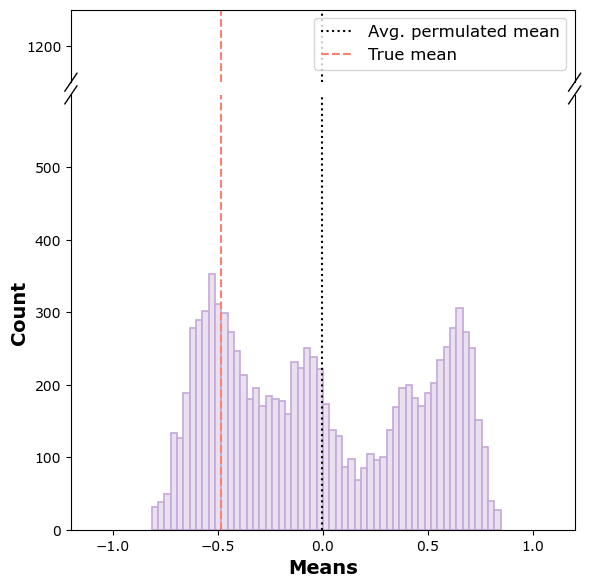

In [89]:
%autoreload 2
ortplot.plot_permulation_stats(
    results,
    "loss",
    # hist_color="black",
    # edgecolor="black",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    xlim=(-1.2, 1.2),
    split_y_axis=True,
    split_y_lims=((0, 600), (1150, 1250)),
    binwidth=0.03
 )

# plt.savefig(str(figure5 + "/loss_all_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

In [84]:
extract_max_bin_values(results, binwidth=0.03)

Max-count bin index: 10
Bin range: [-0.540000, -0.510000)
Count in max bin: 353
Unique values in max bin: 344
Extracted values: 353


(array([-0.52091903, -0.52318725, -0.53775294, -0.52668624, -0.53792807,
        -0.53407599, -0.53306923, -0.51939354, -0.53014647, -0.51695156,
        -0.53085032, -0.52000664, -0.53899073, -0.51436261, -0.53923219,
        -0.52352144, -0.51435026, -0.51859286, -0.52222141, -0.52879015,
        -0.53277487, -0.53092188, -0.52162803, -0.5181481 , -0.51373562,
        -0.51095319, -0.5337652 , -0.51915912, -0.52685058, -0.52992326,
        -0.51768407, -0.52853646, -0.51490444, -0.51190452, -0.51800756,
        -0.53297809, -0.53027926, -0.51540674, -0.52985473, -0.52521963,
        -0.52599587, -0.53631978, -0.52403783, -0.52242082, -0.51403037,
        -0.53485694, -0.51503197, -0.52807201, -0.53133227, -0.51568149,
        -0.52492418, -0.521639  , -0.53206634, -0.51185473, -0.52463979,
        -0.53093846, -0.53478271, -0.5263711 , -0.51461882, -0.53641158,
        -0.5293822 , -0.51841573, -0.53993865, -0.53692547, -0.51045248,
        -0.5257846 , -0.5309693 , -0.51797306, -0.5

## Loss permuted stats, no araneids


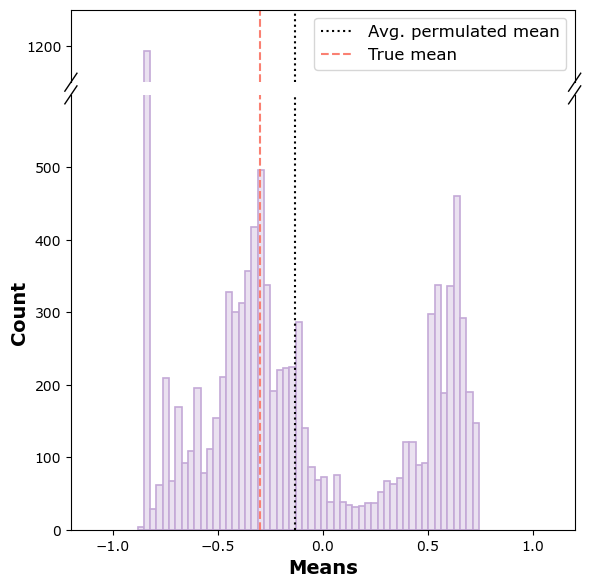

In [90]:
%autoreload 2

ortplot.plot_permulation_stats(
    no_ara_results,
    "loss",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    # hist_color="black",
    # edgecolor="black",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    xlim=(-1.2, 1.2),
    split_y_axis=True,
    split_y_lims=((0, 600), (1150, 1250)),
    binwidth=0.03
 )

plt.savefig(str(figure5 + "/loss_no_ara_stats.png"), dpi=600, bbox_inches="tight", transparent=False)

In [58]:
extract_max_bin_values(no_ara_results, binwidth=0.03)

Max-count bin index: 1
Bin range: [-0.870000, -0.840000)
Count in max bin: 1185
Unique values in max bin: 7
Extracted values: 1185


(array([-0.84047222, -0.84047222, -0.84047222, ..., -0.84047222,
        -0.84047222, -0.84047222], shape=(1185,)),
 array([-0.85086866, -0.84690085, -0.84583002, -0.84552644, -0.84303587,
        -0.84200874, -0.84047222]))

## Loss permuted stats, no tetragnathids

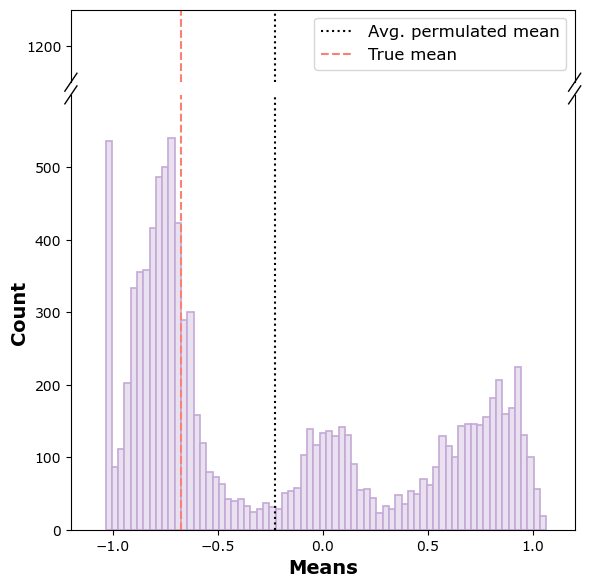

In [88]:
%autoreload 2
ortplot.plot_permulation_stats(
    no_tet_results,
    "loss",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    # hist_color="black",
    # edgecolor="black",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    split_y_axis=True,
    split_y_lims=((0, 600), (1150, 1250)),
    xlim=(-1.2, 1.2),
    binwidth=0.03
 )

plt.savefig(str(figure5 + "/loss_no_tet_stats.png"), dpi=600, bbox_inches="tight", transparent=True)

In [57]:
extract_max_bin_values(no_tet_results, binwidth=0.03)

Max-count bin index: 0
Bin range: [-1.050000, -1.020000)
Count in max bin: 529
Unique values in max bin: 4
Extracted values: 529


(array([-1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02869577,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.02627286, -1.02627286,
        -1.02627286, -1.02627286, -1.02627286, -1.0

## Loss histograms overlaid
All three loss permulated-mean histograms plotted on one axis with shared bins.

All clades: true mean = -0.4856
No araneids: true mean = -0.2989
No tetragnathids: true mean = -0.6740


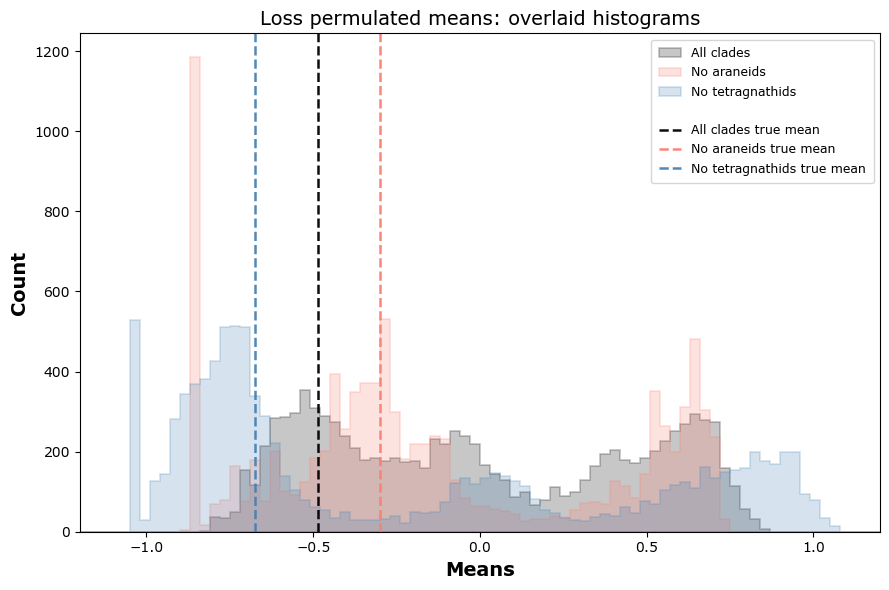

In [108]:
# Shared-bin overlay for the three loss distributions (filled single-axis version)
from matplotlib.lines import Line2D

binwidth = 0.03
xmin, xmax = -1.2, 1.2
bins = np.arange(xmin, xmax + binwidth, binwidth)

series = [
    ("All clades", results.means_loss, results.true_mean_loss, "black"),
    ("No araneids", no_ara_results.means_loss, no_ara_results.true_mean_loss, "salmon"),
    ("No tetragnathids", no_tet_results.means_loss, no_tet_results.true_mean_loss, "steelblue"),
]

fig, ax = plt.subplots(figsize=(9, 6))

for name, vals, true_mean, color in series:
    ax.hist(
        vals,
        bins=bins,
        histtype="stepfilled",
        linewidth=1.3,
        color=color,
        edgecolor=color,
        alpha=0.22,
        label=name,
    )
    ax.axvline(
        true_mean,
        color=color,
        linestyle="--",
        linewidth=1.8,
        alpha=0.95,
        label=f"{name} true mean",
    )

ax.set_xlim((xmin, xmax))
ax.set_xlabel("Means", fontsize=14, fontweight="bold")
ax.set_ylabel("Count", fontsize=14, fontweight="bold")
ax.set_title("Loss permulated means: overlaid histograms", fontsize=14)

# Legend order: histogram fills first, spacer, then mean lines (single column).
handles, labels = ax.get_legend_handles_labels()
hist_handles, hist_labels = [], []
mean_handles, mean_labels = [], []
for h, l in zip(handles, labels):
    if l.endswith(" true mean"):
        mean_handles.append(h)
        mean_labels.append(l)
    else:
        hist_handles.append(h)
        hist_labels.append(l)

spacer = Line2D([], [], linestyle="none")
ordered_handles = hist_handles + [spacer] + mean_handles
ordered_labels = hist_labels + [""] + mean_labels

ax.legend(
    ordered_handles,
    ordered_labels,
    fontsize=9,
    ncol=1,
    frameon=True,
    handlelength=1.8,
    labelspacing=0.5,
    borderpad=0.6,
 )

fig.tight_layout()

for name, _, true_mean, _ in series:
    print(f"{name}: true mean = {true_mean:.4f}")

# plt.savefig(str(figure5 + "/loss_overlay_stats_filled.png"), dpi=600, bbox_inches="tight", transparent=True)

## Duplication permuted stats, all clades included

(<Figure size 650x500 with 1 Axes>,
 array([<Axes: xlabel='Means', ylabel='Count'>], dtype=object))

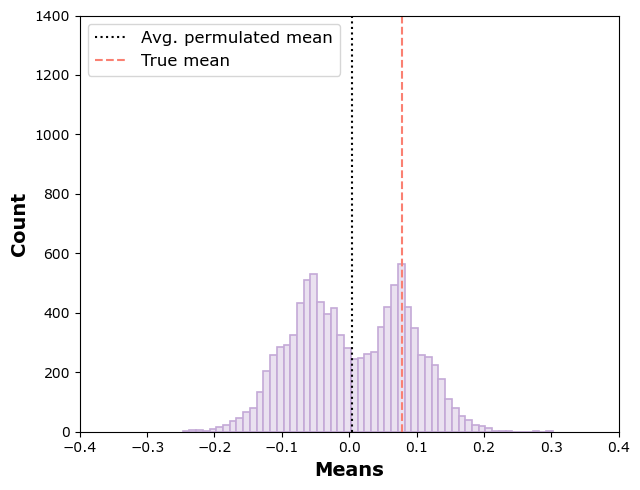

In [69]:

%autoreload 2
ortplot.plot_permulation_stats(
    results,
    "duplication",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    ylim=(0, 1400),
    xlim=(-0.4, 0.4),
    binwidth=0.01
 )

# plt.savefig(str(figure5 + "/dup_all_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

## Duplication permuted stats, no araneids


(<Figure size 650x500 with 1 Axes>,
 array([<Axes: xlabel='Means', ylabel='Count'>], dtype=object))

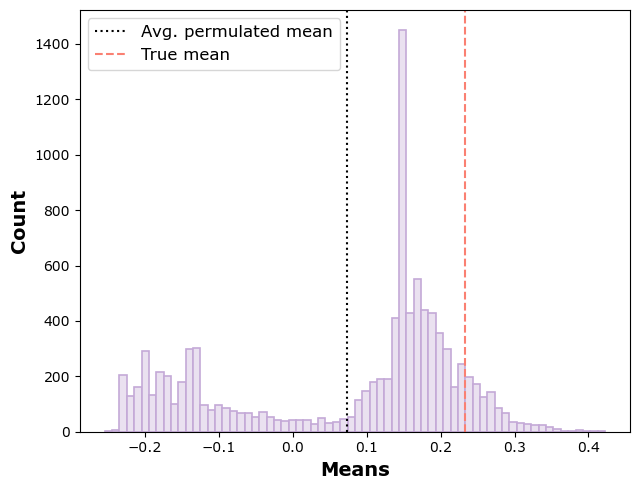

In [100]:
ortplot.plot_permulation_stats(
    no_ara_results,
    "duplication",
    hist_color="#EAE1F0",
    # hist_color="black",
    edgecolor="#C4A9D7",
    # edgecolor="black",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    # split_y_axis=True,
    # split_y_lims=((0, 600), (1100, 1500)),
    # split_y_height_ratios="auto",
    # xlim=(-0.4, 0.4),
    # binwidth=0.002
 )

# plt.savefig(str(figure5 + "/dup_no_ara_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

## Duplication permuted stats, no tetragnathids

(<Figure size 650x500 with 1 Axes>,
 array([<Axes: xlabel='Means', ylabel='Count'>], dtype=object))

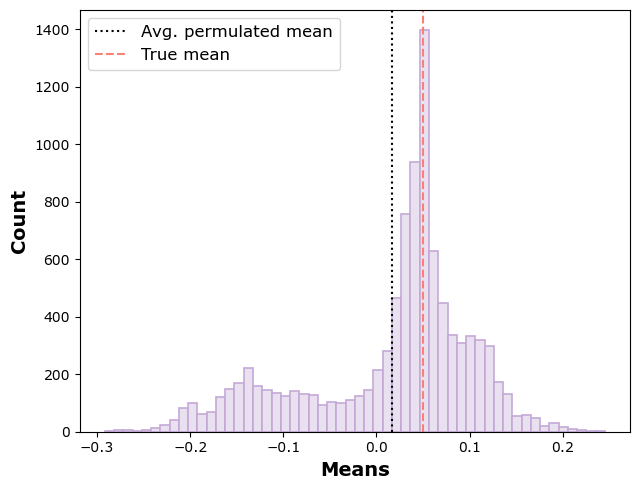

In [97]:
ortplot.plot_permulation_stats(
    no_tet_results,
    "duplication",
    hist_color="#EAE1F0",
    edgecolor="#C4A9D7",
    # hist_color="black",
    # edgecolor="black",
    hist_alpha=1,
    title=False,
    subplot_titles=False,
    legend_fontsize=12,
    axis_label_fontsize=14,
    include_stddev=False,
    # ylim=(0, 600),
    # # xlim=(-0.4, 0.4),
    # # binwidth=0.0009
 )

# plt.savefig(str(figure5 + "/dup_no_tet_stats.png"), dpi=300, bbox_inches="tight", transparent=True)

In [33]:
for label, arr in [("loss", results.means_loss), ("dup", results.means_dup)]:
    values, counts = np.unique(arr, return_counts=True)
    dupe_group_counts = counts[counts > 1]
    print(f"{label}: unique means = {len(values)} of {len(arr)}")
    print(f"{label}: duplicate mean groups = {len(dupe_group_counts)}")
    print(f"{label}: entries in duplicate mean groups = {int(dupe_group_counts.sum())}")
    if len(dupe_group_counts):
        print(f"{label}: largest duplicate group size = {int(dupe_group_counts.max())}")
    print()

loss: unique means = 9782 of 10000
loss: duplicate mean groups = 104
loss: entries in duplicate mean groups = 322
loss: largest duplicate group size = 40

dup: unique means = 9782 of 10000
dup: duplicate mean groups = 104
dup: entries in duplicate mean groups = 322
dup: largest duplicate group size = 40



In this run with no Araneids, there is one permulated tree that appears many times.

In [34]:
for label, arr in [("loss", no_ara_results.means_loss), ("dup", no_ara_results.means_dup)]:
    values, counts = np.unique(arr, return_counts=True)
    dupe_group_counts = counts[counts > 1]
    print(f"{label}: unique means = {len(values)} of {len(arr)}")
    print(f"{label}: duplicate mean groups = {len(dupe_group_counts)}")
    print(f"{label}: entries in duplicate mean groups = {int(dupe_group_counts.sum())}")
    if len(dupe_group_counts):
        print(f"{label}: largest duplicate group size = {int(dupe_group_counts.max())}")
    print()

loss: unique means = 5464 of 10000
loss: duplicate mean groups = 662
loss: entries in duplicate mean groups = 5198
loss: largest duplicate group size = 1174

dup: unique means = 5464 of 10000
dup: duplicate mean groups = 662
dup: entries in duplicate mean groups = 5198
dup: largest duplicate group size = 1174



This was also true in a previous run, using the same species, which generated a non-identical permulation tip values csv.

In [35]:
for label, arr in [("loss", no_ara_results_other_permulation.means_loss), ("dup", no_ara_results_other_permulation.means_dup)]:
    values, counts = np.unique(arr, return_counts=True)
    dupe_group_counts = counts[counts > 1]
    print(f"{label}: unique means = {len(values)} of {len(arr)}")
    print(f"{label}: duplicate mean groups = {len(dupe_group_counts)}")
    print(f"{label}: entries in duplicate mean groups = {int(dupe_group_counts.sum())}")
    if len(dupe_group_counts):
        print(f"{label}: largest duplicate group size = {int(dupe_group_counts.max())}")
    print()

loss: unique means = 5403 of 10000
loss: duplicate mean groups = 727
loss: entries in duplicate mean groups = 5324
loss: largest duplicate group size = 1139

dup: unique means = 5403 of 10000
dup: duplicate mean groups = 727
dup: entries in duplicate mean groups = 5324
dup: largest duplicate group size = 1139



In [36]:
import numpy as np

for label, arr in [("loss", no_tet_results.means_loss), ("dup", no_tet_results.means_dup)]:
    values, counts = np.unique(arr, return_counts=True)
    dupe_group_counts = counts[counts > 1]
    print(f"{label}: unique means = {len(values)} of {len(arr)}")
    print(f"{label}: duplicate mean groups = {len(dupe_group_counts)}")
    print(f"{label}: entries in duplicate mean groups = {int(dupe_group_counts.sum())}")
    if len(dupe_group_counts):
        print(f"{label}: largest duplicate group size = {int(dupe_group_counts.max())}")
    print()

loss: unique means = 8462 of 10000
loss: duplicate mean groups = 455
loss: entries in duplicate mean groups = 1993
loss: largest duplicate group size = 526

dup: unique means = 8462 of 10000
dup: duplicate mean groups = 455
dup: entries in duplicate mean groups = 1993
dup: largest duplicate group size = 526



All clades: true mean = 0.0790
No araneids: true mean = 0.2324
No tetragnathids: true mean = 0.0504


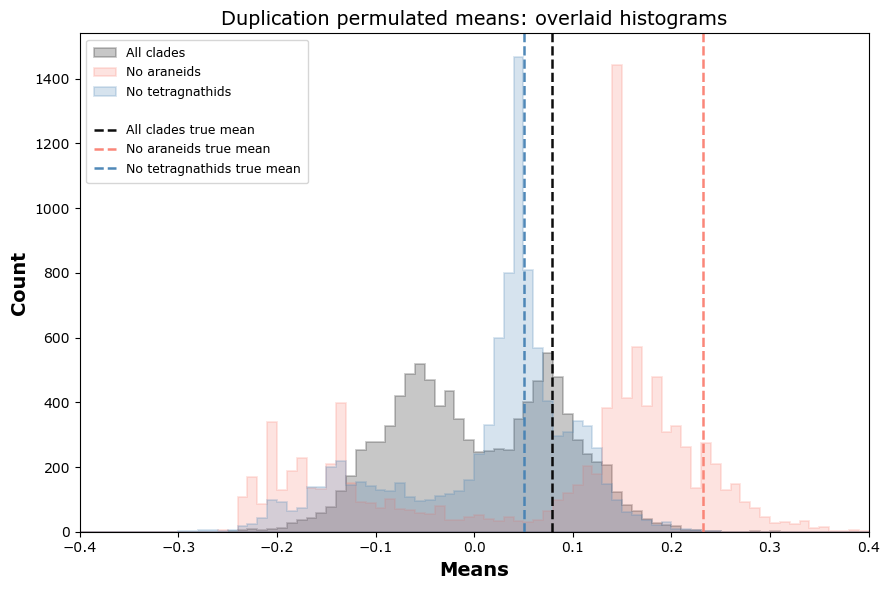

In [109]:
# Shared-bin overlay for the three duplication distributions (filled single-axis version)
from matplotlib.lines import Line2D

binwidth = 0.01
xmin, xmax = -0.4, 0.4
bins = np.arange(xmin, xmax + binwidth, binwidth)

series = [
    ("All clades", results.means_dup, results.true_mean_dup, "black"),
    ("No araneids", no_ara_results.means_dup, no_ara_results.true_mean_dup, "salmon"),
    ("No tetragnathids", no_tet_results.means_dup, no_tet_results.true_mean_dup, "steelblue"),
]

fig, ax = plt.subplots(figsize=(9, 6))

for name, vals, true_mean, color in series:
    ax.hist(
        vals,
        bins=bins,
        histtype="stepfilled",
        linewidth=1.3,
        color=color,
        edgecolor=color,
        alpha=0.22,
        label=name,
    )
    ax.axvline(
        true_mean,
        color=color,
        linestyle="--",
        linewidth=1.8,
        alpha=0.95,
        label=f"{name} true mean",
    )

ax.set_xlim((xmin, xmax))
ax.set_xlabel("Means", fontsize=14, fontweight="bold")
ax.set_ylabel("Count", fontsize=14, fontweight="bold")
ax.set_title("Duplication permulated means: overlaid histograms", fontsize=14)

# Legend order: histogram fills first, spacer, then mean lines (single column).
handles, labels = ax.get_legend_handles_labels()
hist_handles, hist_labels = [], []
mean_handles, mean_labels = [], []
for h, l in zip(handles, labels):
    if l.endswith(" true mean"):
        mean_handles.append(h)
        mean_labels.append(l)
    else:
        hist_handles.append(h)
        hist_labels.append(l)

spacer = Line2D([], [], linestyle="none")
ordered_handles = hist_handles + [spacer] + mean_handles
ordered_labels = hist_labels + [""] + mean_labels

ax.legend(
    ordered_handles,
    ordered_labels,
    fontsize=9,
    ncol=1,
    frameon=True,
    handlelength=1.8,
    labelspacing=0.5,
    borderpad=0.6,
 )

fig.tight_layout()

for name, _, true_mean, _ in series:
    print(f"{name}: true mean = {true_mean:.4f}")

# plt.savefig(str(figure5 + "/dup_overlay_stats_filled.png"), dpi=600, bbox_inches="tight", transparent=True)